<a href="https://colab.research.google.com/github/riccardo03/Quant_preparation/blob/main/ARIMA_and_SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA


In [1]:
import pandas as pd
import numpy as np
import warnings
import itertools
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings("ignore")

# ---1. Load & prepare
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, header=0, names=["month", "passengers"])

df["month"] = pd.to_datetime(df["month"])
df.set_index("month", inplace=True)
df.index.freq = "MS"  # month start frequency
df["log_passengers"] = np.log(df["passengers"])
series = df["log_passengers"]

print(f"Index type  : {type(series.index)}")
print(f"Index sample: {series.index[:3].tolist()}")
print(f"Freq        : {series.index.freq}")

Index type  : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index sample: [Timestamp('1949-01-01 00:00:00'), Timestamp('1949-02-01 00:00:00'), Timestamp('1949-03-01 00:00:00')]
Freq        : <MonthBegin>


<Axes: xlabel='month'>

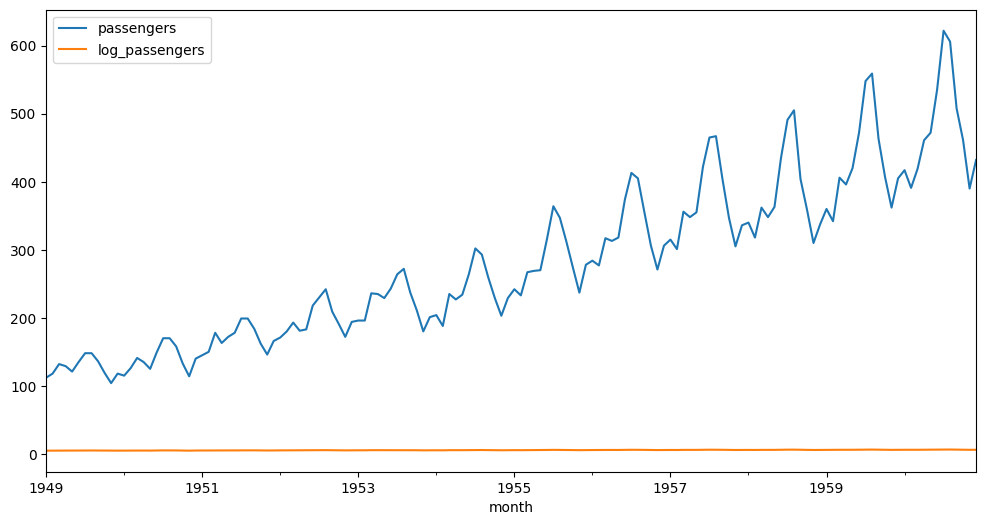

In [2]:
df.plot(figsize=(12, 6))

In [3]:
# ---2. Train / Test split
FORECAST_HORIZON = 12
train = series.iloc[:-FORECAST_HORIZON]
test  = series.iloc[-FORECAST_HORIZON:]

print(f"\nTrain: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} obs)")
print(f"Test : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} obs)")



Train: 1949-01-01 → 1959-12-01 (132 obs)
Test : 1960-01-01  → 1960-12-01  (12 obs)


In [4]:
# how many times should i differenciate?
from statsmodels.tsa.stattools import adfuller, kpss

def check_stationarity(s, label):
    adf_p = adfuller(s.dropna())[1]
    print(f"{label}: ADF p-value = {adf_p:.4f} → {'stationary' if adf_p < 0.05 else 'NOT staTionary'}")

check_stationarity(series,             "Original       ")
check_stationarity(series.diff(),      "First diff  d=1 ")
check_stationarity(series.diff().diff(),"Second diff d=2")

originale       : ADF p-value = 0.4224 → NON stazionaria
prima diff  d=1 : ADF p-value = 0.0711 → NON stazionaria
seconda diff d=2: ADF p-value = 0.0000 → stazionaria


In [5]:
# --- 3. Grid search on TRAIN only
results = []
for p, d, q in itertools.product(range(0,10), range(0,3), range(0,10)):
    try:
        aic = ARIMA(train, order=(p,d,q)).fit().aic
        results.append({"p":p, "d":d, "q":q, "AIC":aic})
    except Exception:
        continue

results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
best = results_df.iloc[0]
p, d, q = int(best.p), int(best.d), int(best.q)
print(f"\nBest model : ARIMA({p},{d},{q})  AIC={best.AIC:.2f}")


Best model : ARIMA(8,2,9)  AIC=-372.48


In [8]:
# --- 4. Fit & forecast
model   = ARIMA(train, order=(p,d,q)).fit()
fc      = model.get_forecast(steps=FORECAST_HORIZON)
fc_mean = fc.predicted_mean
fc_ci   = fc.conf_int(alpha=0.05)


Test index  : [Timestamp('1960-01-01 00:00:00'), Timestamp('1960-02-01 00:00:00'), Timestamp('1960-03-01 00:00:00'), Timestamp('1960-04-01 00:00:00'), Timestamp('1960-05-01 00:00:00'), Timestamp('1960-06-01 00:00:00'), Timestamp('1960-07-01 00:00:00'), Timestamp('1960-08-01 00:00:00'), Timestamp('1960-09-01 00:00:00'), Timestamp('1960-10-01 00:00:00'), Timestamp('1960-11-01 00:00:00'), Timestamp('1960-12-01 00:00:00')]
FC   index  : [Timestamp('1960-01-01 00:00:00'), Timestamp('1960-02-01 00:00:00'), Timestamp('1960-03-01 00:00:00'), Timestamp('1960-04-01 00:00:00'), Timestamp('1960-05-01 00:00:00'), Timestamp('1960-06-01 00:00:00'), Timestamp('1960-07-01 00:00:00'), Timestamp('1960-08-01 00:00:00'), Timestamp('1960-09-01 00:00:00'), Timestamp('1960-10-01 00:00:00'), Timestamp('1960-11-01 00:00:00'), Timestamp('1960-12-01 00:00:00')]


In [9]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:         log_passengers   No. Observations:                  132
Model:                 ARIMA(8, 2, 9)   Log Likelihood                 204.241
Date:                Wed, 08 Apr 2026   AIC                           -372.482
Time:                        14:01:07   BIC                           -320.866
Sample:                    01-01-1949   HQIC                          -351.509
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0040      0.030      0.135      0.893      -0.054       0.062
ar.L2         -0.0074      0.033     -0.224      0.823      -0.073       0.058
ar.L3          0.0645      0.032      2.028      0.0

In [11]:
# --- 5. Back-transform
train_orig    = np.exp(train)
test_orig     = np.exp(test)
fc_orig       = np.exp(fc_mean)
ci_lower_orig = np.exp(fc_ci.iloc[:, 0])
ci_upper_orig = np.exp(fc_ci.iloc[:, 1])

# force index alignment just in case
fc_orig.index       = test_orig.index
ci_lower_orig.index = test_orig.index
ci_upper_orig.index = test_orig.index

In [12]:
# --- 6. SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

# significant lag
candidates = [
    (4, 2, 5),   # AR until L4, MA until L5
    (8, 2, 9),   # actual model
    (4, 2, 9),
    (3, 2, 5),
    (2, 2, 2),
]

print(f"{'Model':<15} {'AIC':>10} {'BIC':>10} {'MAPE':>10}")
print("-" * 45)
for order in candidates:
    try:
        m = SARIMAX(train, order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        fc = np.exp(m.get_forecast(steps=12).predicted_mean)
        fc.index = test_orig.index
        mape = np.mean(np.abs((test_orig - fc) / test_orig)) * 100
        print(f"ARIMA{str(order):<12} {m.aic:>10.2f} {m.bic:>10.2f} {mape:>9.2f}%")
    except:
        continue

Modello                AIC        BIC       MAPE
---------------------------------------------
ARIMA(4, 2, 5)       -232.86    -204.66     12.84%
ARIMA(8, 2, 9)       -319.77    -269.59      6.58%
ARIMA(4, 2, 9)       -252.56    -213.53      9.48%
ARIMA(3, 2, 5)       -236.77    -211.39     11.84%
ARIMA(2, 2, 2)       -205.29    -191.07     11.34%


In [13]:
#  ARIMA(8,2,9) vs SARIMA
candidates_sarima = [
    {"order": (8,2,9), "seasonal_order": (0,0,0,0), "label": "ARIMA(8,2,9)"},
    {"order": (1,1,1), "seasonal_order": (1,1,1,12), "label": "SARIMA(1,1,1)(1,1,1,12)"},
    {"order": (2,1,2), "seasonal_order": (1,1,1,12), "label": "SARIMA(2,1,2)(1,1,1,12)"},
    {"order": (0,1,1), "seasonal_order": (0,1,1,12), "label": "SARIMA(0,1,1)(0,1,1,12)"},  # classic for AirPassengers
]

print(f"{'Model':<35} {'AIC':>10} {'BIC':>10} {'MAPE':>10}")
print("-" * 65)
for cfg in candidates_sarima:
    try:
        m = SARIMAX(train,
                    order=cfg["order"],
                    seasonal_order=cfg["seasonal_order"],
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        fc = np.exp(m.get_forecast(steps=12).predicted_mean)
        fc.index = test_orig.index
        mape = np.mean(np.abs((test_orig - fc) / test_orig)) * 100
        print(f"{cfg['label']:<35} {m.aic:>10.2f} {m.bic:>10.2f} {mape:>9.2f}%")
    except Exception as e:
        print(f"{cfg['label']:<35} FAILED: {e}")

Modello                                    AIC        BIC       MAPE
-----------------------------------------------------------------
ARIMA(8,2,9)                           -319.77    -269.59      6.58%
SARIMA(1,1,1)(1,1,1,12)                -383.83    -370.56      2.31%
SARIMA(2,1,2)(1,1,1,12)                -379.23    -360.72      2.26%
SARIMA(0,1,1)(0,1,1,12)                -392.99    -385.03      2.88%


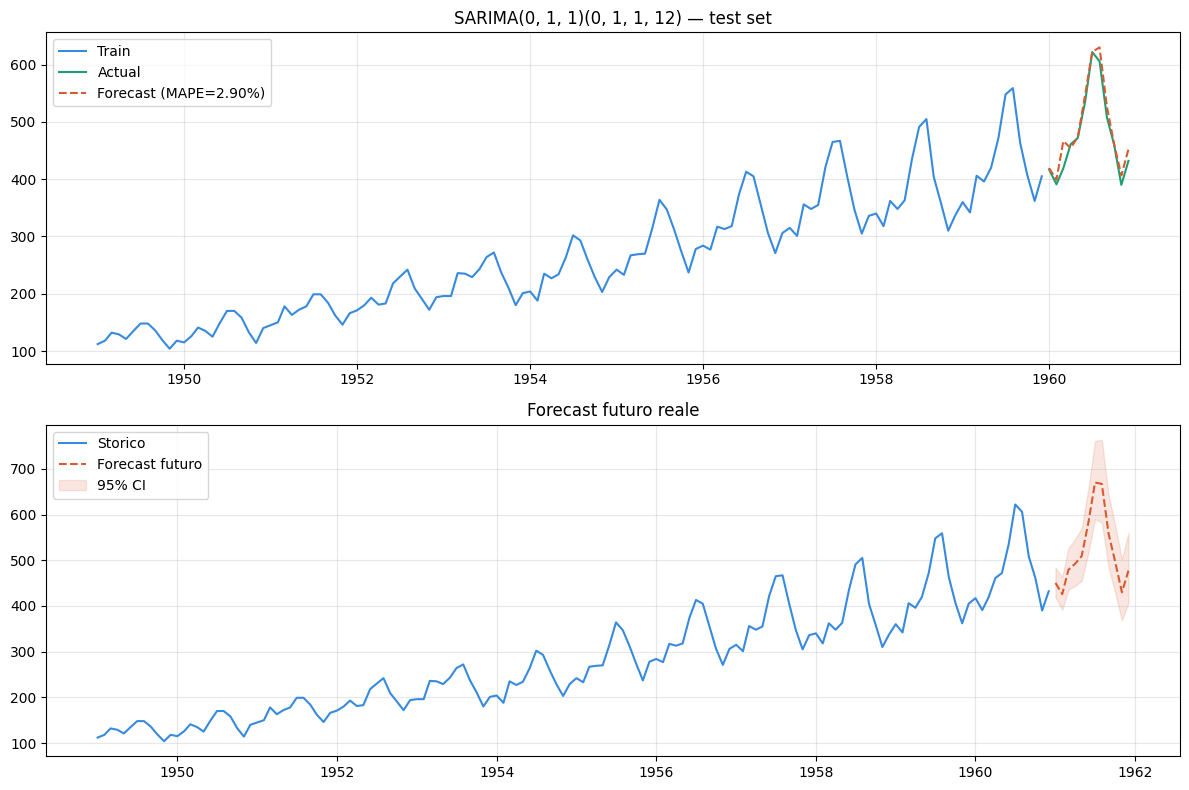

In [17]:
ORDER          = (0, 1, 1)
SEASONAL_ORDER = (0, 1, 1, 12)

# fit on train → valutation
model_eval = SARIMAX(train, order=ORDER, seasonal_order=SEASONAL_ORDER).fit(disp=False)
fc_eval    = np.exp(model_eval.get_forecast(steps=12).predicted_mean)
fc_eval.index = test_orig.index
mape = np.mean(np.abs((test_orig - fc_eval) / test_orig)) * 100

# fit on the whole serie → real future forecast
model_full = SARIMAX(series, order=ORDER, seasonal_order=SEASONAL_ORDER).fit(disp=False)
fc_obj     = model_full.get_forecast(steps=12)
fc_vals    = np.exp(fc_obj.predicted_mean)
fc_ci      = fc_obj.conf_int(alpha=0.05)

# plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
ax.plot(np.exp(train), color="#378ADD", label="Train")
ax.plot(test_orig,     color="#1D9E75", label="Actual")
ax.plot(fc_eval,       color="#D85A30", linestyle="--", label=f"Forecast (MAPE={mape:.2f}%)")
ax.set_title(f"SARIMA{ORDER}{SEASONAL_ORDER} — test set"); ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(np.exp(series), color="#378ADD", label="Storico")
ax2.plot(fc_vals,        color="#D85A30", linestyle="--", label="Forecast futuro")
ax2.fill_between(fc_vals.index,
                 np.exp(fc_ci.iloc[:, 0]),
                 np.exp(fc_ci.iloc[:, 1]),
                 color="#D85A30", alpha=0.15, label="95% CI")
ax2.set_title("Forecast futuro reale"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# --- 7. Comparison table
comparison = pd.DataFrame({
    "actual"   : test_orig.values.round(0).astype(int),
    "forecast" : fc_eval.values.round(0).astype(int),
    "error"    : (test_orig.values - fc_eval.values).round(1),
    "error_%"  : ((test_orig.values - fc_eval.values) / test_orig.values * 100).round(2)
}, index=test_orig.index.strftime("%Y-%m"))

print(f"MAPE: {mape:.2f}%")
print(comparison.to_string())

MAPE: 2.90%
         actual  forecast  error  error_%
month                                    
1960-01     417       419   -2.3    -0.56
1960-02     391       399   -7.9    -2.03
1960-03     419       467  -47.6   -11.35
1960-04     461       454    6.6     1.43
1960-05     472       473   -1.3    -0.27
1960-06     535       547  -12.1    -2.26
1960-07     622       622   -0.2    -0.03
1960-08     606       630  -24.1    -3.98
1960-09     508       527  -18.7    -3.69
1960-10     461       462   -1.3    -0.28
1960-11     390       407  -16.6    -4.26
1960-12     432       452  -20.3    -4.70


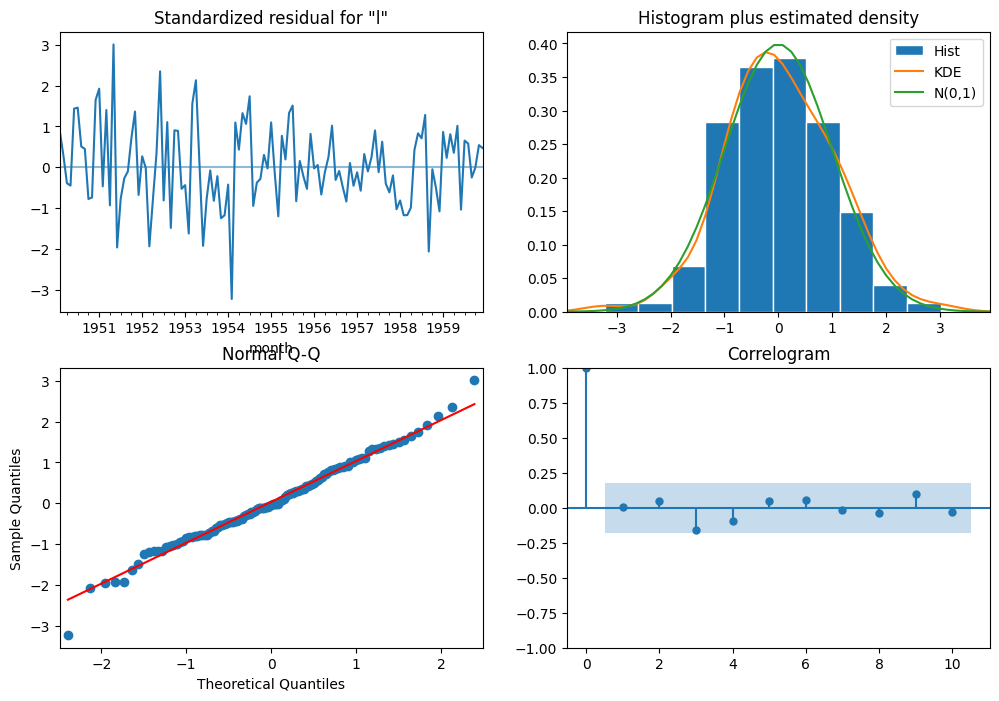

In [25]:
# --- 8. Plot_diagnostics
model_eval.plot_diagnostics(figsize=(12,8))
plt.show()